In [1]:
# Data manipulation and numerical computation
import numpy as np
import pandas as pd
import os

# pandas all columns display
pd.set_option('display.max_columns', None)

# Load data

In [2]:
# before: path = "../../data/processed/"
path = "data/processed"

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

df

SamplingOperations_code CodeSite_SamplingOperations_x  \
2703       S02115200_20070702                     S02115200   
33984      S05218450_20070709                     S05218450   
33929      S05217350_20070709                     S05217350   
48228      S05235850_20070709                     S05235850   
35408      S05234290_20070709                     S05234290   
...                       ...                           ...   
42720      S06580577_20230907                     S06580577   
35760      S06001284_20230907                     S06001284   
35783      S06001533_20230907                     S06001533   
38878      S06137040_20231011                     S06137040   
38873      S06137014_20231011                     S06137014   

      Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
2703              2007-07-02                               400      NaN   
33984             2007-07-09                               400      NaN   
33929             2007-07-09                               400      NaN   
48228             2007-07-09                               400      NaN   
35408             2007-07-09                               400      NaN   
...                      ...                               ...      ...   
42720             2023-09-07                               426      NaN   
35760             2023-09-07                               421      NaN   
35783             2023-09-07                               401      NaN   
38878             2023-10-11                               400      NaN   
38873             2023-10-11                               405      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      2.5      NaN      NaN      NaN      NaN      NaN   
35408      NaN      7.5      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

         Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
2703         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929   5.000000      NaN      NaN      NaN      NaN      NaN      NaN   
48228  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
35408  20.000000      NaN      NaN      NaN      NaN      NaN      NaN   
...          ...      ...      ...      ...      ...      ...      ...   
42720   4.694836      NaN      NaN      NaN      NaN      NaN      NaN   
35760        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783  14.962594      NaN      NaN      NaN      NaN      NaN      NaN   
38878  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
38873  69.135802      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
2703       NaN      NaN      NaN      NaN      NaN      NaN     12.5      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN    

In [3]:
pd.set_option('display.max_columns', 8)
df

,SamplingOperations_code,CodeSite_SamplingOperations_x,Date_SamplingOperation,TotalAbundance_SamplingOperation,...,Mean90Days_XOMP,IBD,IBD_EQR,IBD_EQR_Status
2703,S02115200_20070702,S02115200,2007-07-02,400,...,NaN,10.5,0.555556,Moderate
33984,S05218450_20070709,S05218450,2007-07-09,400,...,NaN,20.0,1.000000,High
33929,S05217350_20070709,S05217350,2007-07-09,400,...,NaN,20.0,1.000000,High
48228,S05235850_20070709,S05235850,2007-07-09,400,...,NaN,NaN,NaN,NaN
35408,S05234290_20070709,S05234290,2007-07-09,400,...,NaN,16.6,0.773333,Moderate
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,S06580577,2023-09-07,426,...,NaN,14.5,0.633333,Moderate
35760,S06001284_20230907,S06001284,2023-09-07,421,...,NaN,16.3,0.753333,Moderate
35783,S06001533_20230907,S06001533,2023-09-07,401,...,NaN,14.8,0.653333,Moderate
38878,S06137040_20231011,S06137040,2023-10-11,400,...,NaN,20.0,1.000000,High


They are **different species** with **different ecology**, so their IBD calibrations typically differ. Do **not** collapse them for official IBD; for ML, collapse only if validated on held-out sites.

* **Achnanthes coarctata**: aerophilic, often on wet moss/rocks; distinct habitat signal. ([Diatoms.org][1])
* **Achnanthes conspicua**: now **Platessa conspicua** (reclassified), so collapsing by the “Achco” stem mixes genera. ([Diatoms.org][2])
* **Achnanthes convergens**: reported as prevalent and adaptable in rivers, implying a different tolerance profile. ([MDPI][3])

If you lack the s,v table, assume they are not interchangeable. Collapse only if genus weight is small and grouped-CV shows unchanged MAE after merging.

[1]: https://diatoms.org/species/47801/achnanthes_coarctata?utm_source=chatgpt.com "Achnanthes coarctata | Species"
[2]: https://diatoms.org/genera/platessa/guide?utm_source=chatgpt.com "Guide to Platessa | Genera"
[3]: https://www.mdpi.com/2073-4441/14/6/956?utm_source=chatgpt.com "A Case Study in the Han River, South Korea"


# Knwon NaN values percentage per column

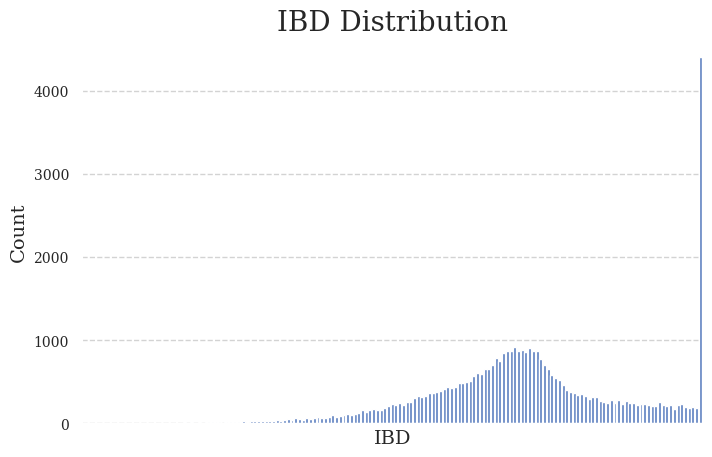

In [4]:
# plot the IBD distribution
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='IBD')
plt.title('IBD Distribution')
plt.xlabel('IBD')
plt.ylabel('Count')
plt.xticks([])
plt.show()

In [5]:
from scripts import latex2md

import pyperclip

pyperclip.copy(latex2md.latex_to_markdown(pyperclip.paste()))

Don’t truncate. You have a **right-censored** target at 20. Treat it as censoring, not noise.

## Do this

1. **Flag censoring**
   $C=\mathbb{1}{\text{IBD}\ge 19.9}$.

2. **Two–model pipeline**

   * **Classifier**: predict $p=\Pr(C=1\mid X)$.
   * **Regressor**: train on **uncensored** rows $IBD<19.9$.
     Predict: if $p>\tau$ (e.g., 0.5) output 20; else use regressor; clip to ([0,20]).

3. **Stronger variant (expected value)**
   Let $\hat\mu$ and $\hat\sigma$ be regressor’s mean and residual std on uncensored data. For censored case, output the **truncated mean**
   $E[Y\mid Y\le 20]=\hat\mu-\hat\sigma\frac{\phi(a)}{\Phi(a)}$, with $a=(20-\hat\mu)/\hat\sigma$. Otherwise use $\hat\mu$. (Approximate (\hat\sigma) globally.)

4. **Quantile guardrails**
   Fit XGBoost **quantile** models at $\tau={0.1,0.5,0.9}$ on uncensored data, then:

   * if $p>\tau$ → set median to 20 and adjust band to $[q_{0.1},20]$
   * else use the median; always clip ([0,20]).

5. **Features**
   Keep raw taxa + space–time features; add the presence flags of abundant taxa; no label transforms needed.

6. **Validation**
   Forward-time + spatial-block CV. Report: MAE on uncensored, fraction of correctly detected $C=1$, and overall clipped-MAE.

## Don’t

* Don’t drop the 20s or jitter them.
* Don’t standardize the target beyond simple clipping; trees don’t need it.

This preserves the ceiling information and avoids bias from pretending 20 is a precise uncensored value.


# ILRapids

In [6]:
# conda:  conda create -n rapids -c rapidsai -c conda-forge rapids=24.08 python=3.10 cuda-version=12.2
import cupy as cp, cudf

In [7]:
from scripts import cleandf

# restart cleandf
import importlib
importlib.reload(cleandf)

<module 'scripts.cleandf' from '/home/yupi/Clasificacion-de-Calidad-del-Agua-IBD-EQR/scripts/cleandf.py'>

In [8]:
xcleaned = cleandf.IWANTMYXCLEAN(df)

Dropped exact duplicate columns: ['Cocps01', 'Dipde01', 'Dippa01', 'Encsu01', 'Encsu02', 'Ethpu01', 'Grama01', 'Navpa06', 'Navth01', 'Navtr01', 'Nitth01', 'Parhe01', 'Plata01', 'Semro01', 'Synaf01', 'Thani01', 'Mean1Y_1770', 'Mean90Days_2923']
Dropped columns with >95% missing: ['Achaa01', 'Achac01', 'Achaf01', 'Achaf02', 'Achal01', 'Acham01', 'Achan01', 'Achat01', 'Achat03', 'Achba01', 'Achbi01', 'Achbi02', 'Achbr01', 'Achca01', 'Achca03', 'Achca04', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achco04', 'Achcr01', 'Achcy01', 'Achda01', 'Achda02', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex01', 'Achex02', 'Achex03', 'Achfl01', 'Achfr01', 'Achfu01', 'Achgr01', 'Achgr02', 'Achgr03', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achho03', 'Achhu01', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achja01', 'Achja02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr02', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla03', 'Achla05', 'Achla06', 'Achl

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
xcleaned

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180Days_1

In [10]:
# ===================== IBD Censored-at-20 Pipeline (XGBoost) =====================
# pip install xgboost pandas numpy scikit-learn
import numpy as np
import pandas as pd
from xgboost import XGBRegressor, XGBClassifier

CENSOR_LEVEL = 20.0
CENSOR_THRESH = 19.9  # treat >=19.9 as censored

# ---------- feature engineering ----------
ID_COLS = {"SamplingOperations_code", "CodeSite_SamplingOperations"}
META_COLS = {"Date_SamplingOperation", "Longitude_Lambert93", "Latitude_Lambert93",
             "TotalAbundance_SamplingOperation", "Watershed", "IBD"}

             # --- put this near the top ---
import math

def normal_cdf_array(x: np.ndarray) -> np.ndarray:
    # Φ(x) = 0.5 * (1 + erf(x / sqrt(2)))
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / np.sqrt(2.0)))


def _space_time_feats(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["Date_SamplingOperation"])
    out["month_sin"] = np.sin(2*np.pi*dt.dt.month/12).astype(np.float32)
    out["month_cos"] = np.cos(2*np.pi*dt.dt.month/12).astype(np.float32)
    out["year"] = dt.dt.year.astype(np.int16)
    out["x"] = out["Longitude_Lambert93"].astype(np.float32)
    out["y"] = out["Latitude_Lambert93"].astype(np.float32)
    return out

def _detect_taxa_cols(df: pd.DataFrame, min_prev=0.05):
    excluded = ID_COLS | META_COLS | {"x","y","month_sin","month_cos","year"}
    num_cols = [c for c in df.columns if c not in excluded and np.issubdtype(df[c].dtype, np.number)]
    keep = [c for c in num_cols if df[c].notna().mean() >= min_prev]
    return keep

def _add_proportions(df: pd.DataFrame, taxa_cols):
    out = df.copy()
    if "TotalAbundance_SamplingOperation" in out.columns:
        TA = out["TotalAbundance_SamplingOperation"].replace(0, np.nan).astype(np.float32)
        props = out[taxa_cols].astype(np.float32).div(TA, axis=0)
        props = props.add_prefix("prop_")
        out = pd.concat([out, props], axis=1)
    return out

def make_features(df: pd.DataFrame, min_taxa_prev=0.05, add_watershed=True, add_proportions=True):
    X = _space_time_feats(df)
    taxa = _detect_taxa_cols(X, min_prev=min_taxa_prev)
    if add_proportions and "TotalAbundance_SamplingOperation" in X.columns:
        X = _add_proportions(X, taxa)
        prop_cols = [f"prop_{c}" for c in taxa]
    else:
        prop_cols = []
    feats = ["x","y","month_sin","month_cos","year","TotalAbundance_SamplingOperation"] + taxa + prop_cols
    if add_watershed and "Watershed" in X.columns:
        dummies = pd.get_dummies(X["Watershed"], prefix="ws", dummy_na=False)
        X = pd.concat([X, dummies], axis=1)
        feats += list(dummies.columns)
    return X, feats

# ---------- training ----------
def train_censored_pipeline(df: pd.DataFrame,
                            min_taxa_prev=0.05,
                            use_gpu=True,
                            clf_params=None,
                            reg_params=None):
    Xall, feat_cols = make_features(df, min_taxa_prev)

    # masks
    m_has_y = df["IBD"].notna()
    y = df.loc[m_has_y, "IBD"].astype(np.float32)
    C = (y >= CENSOR_THRESH).astype(np.int8)  # 1 = censored-at-top

    # classifier: predict P(censored)
    X_clf = Xall.loc[m_has_y, feat_cols]
    if clf_params is None:
        clf_params = dict(
            n_estimators=600, max_depth=7, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.6, reg_lambda=1.0,
            tree_method="hist", scale_pos_weight=max(1.0, (len(C)-C.sum())/max(1,C.sum()))
        )
    if use_gpu: clf_params["device"] = "cuda"
    clf = XGBClassifier(**clf_params)
    clf.fit(X_clf, C)

    # regressor: only uncensored rows
    unc = (y < CENSOR_THRESH)
    X_reg = X_clf.loc[unc]
    y_reg = y.loc[unc]
    if reg_params is None:
        reg_params = dict(
            n_estimators=1200, max_depth=8, learning_rate=0.03,
            subsample=0.7, colsample_bytree=0.6, reg_lambda=2.0,
            tree_method="hist"
        )
    if use_gpu: reg_params["device"] = "cuda"
    reg = XGBRegressor(**reg_params)
    reg.fit(X_reg, y_reg)

    # estimate residual sigma on uncensored (for truncated-mean option)
    y_hat_in = reg.predict(X_reg).astype(np.float32)
    sigma = float(np.sqrt(np.mean((y_hat_in - y_reg.values)**2)))  # RMSE

    state = {
        "feat_cols": feat_cols,
        "clf": clf,
        "reg": reg,
        "sigma_unc": sigma
    }
    return state

# ---------- prediction ----------
def _phi(x):  # standard normal pdf
    return np.exp(-0.5*x*x)/np.sqrt(2*np.pi)
def _Phi(x):  # standard normal cdf (approx)
    # erf-based approximation
    return 0.5*(1.0 + np.math.erf(x/np.sqrt(2)))

def predict_censored(df: pd.DataFrame, state: dict,
                     p_thresh=0.5, mode="rule"):
    """
    mode:
      - "rule": if P(censor)>p_thresh -> 20, else regressor
      - "truncmean": use truncated-normal mean above when censoring predicted
    """
    Xall, feat_cols = make_features(df)
    clf, reg = state["clf"], state["reg"]
    sigma = max(1e-6, state["sigma_unc"])

    # predict only where IBD is NaN
    m_q = df["IBD"].isna()
    out = np.full(len(df), np.nan, dtype=np.float32)
    if not m_q.any(): 
        return out

    Xq = Xall.loc[m_q, feat_cols]
    p_cen = clf.predict_proba(Xq)[:,1]
    y_mu  = reg.predict(Xq).astype(np.float32)

    if mode == "rule":
        y_pred = y_mu
        y_pred[p_cen >= p_thresh] = CENSOR_LEVEL
    elif mode == "truncmean":
        # expected value under right-censoring at 20:
        # E[Y | Y<=20] for Gaussian approx on residuals about mu
        a = (CENSOR_LEVEL - y_mu) / sigma
        Phi = normal_cdf_array(a).astype(np.float32)
        phi = (np.exp(-0.5 * a * a) / np.sqrt(2.0 * np.pi)).astype(np.float32)
        tm  = y_mu - sigma * (phi / np.clip(Phi, 1e-6, 1.0))

        y_pred = np.where(p_cen >= p_thresh, np.minimum(CENSOR_LEVEL, tm), y_mu)
    else:
        raise ValueError("mode must be 'rule' or 'truncmean'")

    # clip to [0, 20]
    y_pred = np.clip(y_pred, 0.0, CENSOR_LEVEL).astype(np.float32)
    out[m_q.to_numpy()] = y_pred
    return out

# ---------- end-to-end convenience ----------
def fit_and_fill_censored(df: pd.DataFrame,
                          min_taxa_prev=0.05,
                          use_gpu=True,
                          mode="rule",
                          p_thresh=0.5):
    state = train_censored_pipeline(df, min_taxa_prev=min_taxa_prev, use_gpu=use_gpu)
    ibd_hat = predict_censored(df, state, p_thresh=p_thresh, mode=mode)
    out = df.copy()
    out["IBD_hat"] = ibd_hat
    return out, state


In [11]:
# make them have the same index
df = df.set_index(xcleaned.index)

In [14]:
# add longitude, latitude, total abundance, SamplingOperations_code, CodeSite_SamplingOperations_x, Date_SamplingOperation, TotalAbundance_SamplingOperation
xcleaned = xcleaned.merge(
    df[[
        "Longitude_Lambert93", "Latitude_Lambert93", "TotalAbundance_SamplingOperation",
        "CodeSite_SamplingOperations_x", "Date_SamplingOperation",
        "TotalAbundance_SamplingOperation"
    ]],
    left_index=True,
    right_index=True,
    how='left'
)


In [15]:

# drop IBD_EQR and IBD_EQR_Status 
xcleaned = xcleaned.drop(columns=["IBD_EQR", "IBD_EQR_Status"])
xcleaned

,TotalAbundance_SamplingOperation_x,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93_x,Latitude_Lambert93_x,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180

In [16]:
df = None

In [17]:
# remove duplicate columns
xcleaned = xcleaned.loc[:,~xcleaned.columns.duplicated()]
xcleaned

,TotalAbundance_SamplingOperation_x,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93_x,Latitude_Lambert93_x,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180

In [18]:
# drop Longitude_Lambert93_y	Latitude_Lambert93_y	TotalAbundance_SamplingOperation_y	CodeSite_SamplingOperations_x_y	Date_SamplingOperation_y
xcleaned = xcleaned.drop(columns=[
    "Longitude_Lambert93_y", "Latitude_Lambert93_y",
    "TotalAbundance_SamplingOperation_y",
    "CodeSite_SamplingOperations_x_y",
    "Date_SamplingOperation_y"
])																																																																				

In [19]:
# rename Date_SamplingOperation_x to Date_SamplingOperation
xcleaned = xcleaned.rename(columns={"Date_SamplingOperation_x": "Date_SamplingOperation"})
xcleaned

,TotalAbundance_SamplingOperation_x,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93_x,Latitude_Lambert93_x,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180

In [20]:
# remove the suffix _x and _y from any remaining columns
xcleaned.columns = [col.replace('_x', '') for col in xcleaned.columns]

In [12]:
# Train on rows with IBD present; fill only NaNs in IBD_hat
filled_df, state = fit_and_fill_censored(
    df=df,
    min_taxa_prev=0.05,
    use_gpu=True,        # uses GPU if available in your XGBoost build
    mode="truncmean",    # or "rule"
    p_thresh=0.5
)


/home/yupi/miniconda3/envs/rapids-25.10/lib/python3.13/site-packages/xgboost/core.py:705: UserWarning: [22:29:35] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1758751550967/work/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [22]:
filled_df

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,CodeSite_SamplingOperations_y,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1176,Mean180Days_1177,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180Days_1

In [13]:
filled_df

,SamplingOperations_code,CodeSite_SamplingOperations_x,Date_SamplingOperation,TotalAbundance_SamplingOperation,...,IBD,IBD_EQR,IBD_EQR_Status,IBD_hat
SamplingOperations_code,,,,,,,,,
S02115200_20070702,S02115200_20070702,S02115200,2007-07-02,400,...,10.5,0.555556,Moderate,NaN
S05218450_20070709,S05218450_20070709,S05218450,2007-07-09,400,...,20.0,1.000000,High,NaN
S05217350_20070709,S05217350_20070709,S05217350,2007-07-09,400,...,20.0,1.000000,High,NaN
S05235850_20070709,S05235850_20070709,S05235850,2007-07-09,400,...,NaN,NaN,NaN,19.723068
S05234290_20070709,S05234290_20070709,S05234290,2007-07-09,400,...,16.6,0.773333,Moderate,NaN
...,...,...,...,...,...,...,...,...,...
S06580577_20230907,S06580577_20230907,S06580577,2023-09-07,426,...,14.5,0.633333,Moderate,NaN
S06001284_20230907,S06001284_20230907,S06001284,2023-09-07,421,...,16.3,0.753333,Moderate,NaN
S06001533_20230907,S06001533_20230907,S06001533,2023-09-07,401,...,14.8,0.653333,Moderate,NaN


In [14]:
filled_df.to_parquet('notebooks/14 XGBoost/models/XGB_filled_nocv_truncmean_all_data.parquet')

In [27]:
df = pd.read_parquet('notebooks/14 XGBoost/models/XGB_filled_nocv_truncmean.parquet')

In [28]:
# Get the predictions where IBD_hat is NOT Nan
ypred = df['IBD_hat'].isnull()
ypred = df[~ypred]
ypred = ypred[['IBD_hat']]
ypred

,IBD_hat
SamplingOperations_code,
S05235850_20070709,20.000000
S05113000_20070723,8.645994
S05082000_20070724,14.171203
S05111500_20070724,10.933224
S05086000_20070725,14.893180
...,...
S06173650_20230720,15.416569
S06076420_20230726,17.646275
S06830139_20230818,17.758928


In [29]:
from scripts import mapping

In [30]:
ranges = mapping.get_ranges(tol = 1)
ranges

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,ALPES INTERNES,Bad,-1.000,9.800,9.30
1,ALPES INTERNES,Poor,9.800,13.225,10.30
2,ALPES INTERNES,Moderate,13.225,17.025,16.15
3,ALPES INTERNES,Good,17.025,18.725,17.90
4,ALPES INTERNES,High,18.725,21.000,19.55
...,...,...,...,...,...
105,VOSGES,Bad,-1.000,9.550,7.90
106,VOSGES,Poor,9.550,12.775,11.20
107,VOSGES,Moderate,12.775,15.700,14.35
108,VOSGES,Good,15.700,18.075,17.05


In [31]:
mapping.get_results(
    yhat = ypred,
    ranges = ranges,
    pred_col = "IBD_hat",
    output_file = "IBD_EQR_Status_predictions2.csv"
)

Saved predictions to IBD_EQR_Status_predictions2.csv


,IBD_EQR_Status
SamplingOperations_code,
S05235850_20070709,High
S05113000_20070723,Bad
S05082000_20070724,Moderate
S05111500_20070724,Poor
S05086000_20070725,Moderate
...,...
S06173650_20230720,Moderate
S06076420_20230726,Good
S06830139_20230818,Good


In [22]:
# get all the regions by HERlvl1Name 
dfs = {}
for region in ranges['HERlvl1Name'].unique():
    dfs[region] = df[df['HERlvl1Name'] == region]

In [25]:
# ================= Multiclass IBD_EQR_Status per-region (weighted XGBoost) =================
# pip install xgboost pandas numpy scikit-learn
import numpy as np, pandas as pd
from xgboost import XGBClassifier

# ----- config -----
LABELS = ["High","Good","Moderate","Poor","Bad"]   # keep this exact order if you want ordinal meaning
LABEL2ID = {c:i for i,c in enumerate(LABELS)}
ID2LABEL = {i:c for c,i in LABEL2ID.items()}

ID_COLS = {"SamplingOperations_code", "CodeSite_SamplingOperations"}
META_COLS = {"Date_SamplingOperation","Longitude_Lambert93","Latitude_Lambert93",
             "TotalAbundance_SamplingOperation","Watershed","IBD","IBD_EQR","IBD_EQR_Status"}

# ----- feature engineering -----
def space_time_feats(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["Date_SamplingOperation"])
    out["month_sin"] = np.sin(2*np.pi*dt.dt.month/12).astype(np.float32)
    out["month_cos"] = np.cos(2*np.pi*dt.dt.month/12).astype(np.float32)
    out["year"] = dt.dt.year.astype(np.int16)
    out["x"] = out["Longitude_Lambert93"].astype(np.float32)
    out["y"] = out["Latitude_Lambert93"].astype(np.float32)
    return out

def detect_taxa_cols(df: pd.DataFrame, min_prev=0.05):
    excluded = ID_COLS | META_COLS | {"x","y","month_sin","month_cos","year"}
    num = [c for c in df.columns if c not in excluded and np.issubdtype(df[c].dtype, np.number)]
    return [c for c in num if df[c].notna().mean() >= min_prev]

def add_proportions(df: pd.DataFrame, taxa_cols):
    out = df.copy()
    if "TotalAbundance_SamplingOperation" in out.columns:
        TA = out["TotalAbundance_SamplingOperation"].replace(0, np.nan).astype(np.float32)
        props = out[taxa_cols].astype(np.float32).div(TA, axis=0)
        props = props.add_prefix("prop_")
        out = pd.concat([out, props], axis=1)
    return out

def make_features(df: pd.DataFrame, min_taxa_prev=0.05, add_watershed=True, add_props=True):
    X = space_time_feats(df)
    taxa = detect_taxa_cols(X, min_prev=min_taxa_prev)
    prop_cols = []
    if add_props and "TotalAbundance_SamplingOperation" in df.columns:
        X = add_proportions(X, taxa)
        prop_cols = [f"prop_{c}" for c in taxa]
    feats = ["x","y","month_sin","month_cos","year","TotalAbundance_SamplingOperation"] + taxa + prop_cols
    if add_watershed and "Watershed" in X.columns:
        dummies = pd.get_dummies(X["Watershed"], prefix="ws", dummy_na=False)
        X = pd.concat([X, dummies], axis=1)
        feats += list(dummies.columns)
    return X, feats

# ----- class weights -----
def class_weights(y_ids: np.ndarray, power: float = 1.0):
    vals, cnt = np.unique(y_ids, return_counts=True)
    freq = cnt / cnt.sum()
    w = {int(v): float((1.0/f)**power) for v,f in zip(vals,freq)}
    # normalize so mean weight ≈1
    mean_w = np.mean([w[int(i)] for i in y_ids])
    for k in w: w[k] /= mean_w if mean_w>0 else 1.0
    return w

# ----- per-region train/predict -----
def train_region_clf(df_region: pd.DataFrame,
                     min_taxa_prev=0.05,
                     use_gpu=True,
                     params=None):
    Xall, feats = make_features(df_region, min_taxa_prev)
    m_train = df_region["IBD_EQR_Status"].notna()
    if m_train.sum() == 0:
        return None, feats   # nothing to train

    y_txt = df_region.loc[m_train, "IBD_EQR_Status"].astype(str)
    # map any lowercase/variants to canonical labels
    y_txt = y_txt.str.strip().str.title()
    y_ids = y_txt.map(LABEL2ID).fillna(-1).astype(int).to_numpy()
    keep = y_ids >= 0
    Xtr = Xall.loc[m_train].iloc[keep][feats]
    y_ids = y_ids[keep]

    # sample weights for imbalance
    cw = class_weights(y_ids, power=1.0)
    wtr = np.array([cw[int(i)] for i in y_ids], dtype=np.float32)

    if params is None:
        params = dict(
            n_estimators=1200, max_depth=8, learning_rate=0.03,
            subsample=0.7, colsample_bytree=0.6, reg_lambda=2.0,
            objective="multi:softprob", num_class=len(LABELS),
            tree_method="hist",
        )
    if use_gpu:
        params["device"] = "cuda"  # if your xgboost build supports it

    clf = XGBClassifier(**params)
    clf.fit(Xtr, y_ids, sample_weight=wtr)
    return clf, feats

def predict_and_fill_region(df_region: pd.DataFrame, clf, feats):
    out = df_region.copy()
    if clf is None:
        out["IBD_EQR_Status_hat"] = np.nan
        return out
    Xall, _ = make_features(df_region)
    m_q = df_region["IBD_EQR_Status"].isna()
    yhat = np.full(len(df_region), np.nan, dtype=object)
    if m_q.any():
        proba = clf.predict_proba(Xall.loc[m_q, feats])
        ids = proba.argmax(axis=1)
        yhat[m_q.to_numpy()] = [ID2LABEL[int(i)] for i in ids]
    out["IBD_EQR_Status_hat"] = yhat
    return out

# ----- end-to-end over your dict dfs -----
def fit_and_fill_status_by_region(dfs: dict,
                                  min_taxa_prev=0.05,
                                  use_gpu=True,
                                  params=None):
    models = {}
    filled = {}
    for region, df in dfs.items():
        clf, feats = train_region_clf(df, min_taxa_prev=min_taxa_prev, use_gpu=use_gpu, params=params)
        models[region] = {"clf": clf, "feats": feats}
        filled[region] = predict_and_fill_region(df, clf, feats)
    return filled, models


In [ ]:
filled, models = fit_and_fill_status_by_region(

/home/yupi/miniconda3/envs/rapids-25.10/lib/python3.13/site-packages/xgboost/core.py:705: UserWarning: [23:41:40] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1758751550967/work/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


({'ALPES INTERNES':                         SamplingOperations_code CodeSite_SamplingOperations_x  \
  SamplingOperations_code                                                         
  S06154250_20080304           S06154250_20080304                     S06154250   
  S06141520_20080305           S06141520_20080305                     S06141520   
  S06140010_20080305           S06140010_20080305                     S06140010   
  S06133000_20080311           S06133000_20080311                     S06133000   
  S06132900_20080311           S06132900_20080311                     S06132900   
  ...                                         ...                           ...   
  S06132950_20230830           S06132950_20230830                     S06132950   
  S06132870_20230830           S06132870_20230830                     S06132870   
  S06132600_20230830           S06132600_20230830                     S06132600   
  S06137040_20231011           S06137040_20231011                    